In [141]:
import numpy as np
import pandas as pd
import yfinance as yf
import quantstats as qs
import matplotlib.pyplot as plt
from datetime import datetime

# Import Coins Data

In [9]:
coins = ("BTC-USD", "ETH-USD", "XRP-USD", "SOL-USD", "DOGE-USD")

start = datetime(2024, 1, 1)
end = datetime(2024, 11, 1)

In [10]:
price_dict = {}
for coin in coins:
    data = yf.Ticker(coin).history(interval="1d", start=start, end=end)
    price_dict[coin] = data.Close

prices_df = pd.DataFrame(price_dict)

# Buy and Hold Strategy Backtest and Measurements

In [30]:
def first_price(series: pd.DataFrame, coin: str) -> float:
    return series.iloc[0][coin]

In [31]:
def get_share(coin: str, fund: float, price: float, weight: float) -> float:
    return (fund * weight) / price

In [73]:
def get_stocks_return(series: pd.DataFrame) -> pd.DataFrame:
    return series.pct_change()

In [148]:
def backtest(series: pd.DataFrame, fund: int, weights: dict) -> pd.Series:
    initial_prices = {coin: first_price(series, coin) for coin in series.columns}
    shares = {
        coin: get_share(coin, fund, initial_prices[coin], weights[index])
        for index, coin in enumerate(series.columns.tolist())
    }
    portfolio_daily = pd.DataFrame([None for _ in series.index], index=series.index)
    portfolio_daily.columns = ["Value"]
    coins = series.columns
    fee = 0.5
    for day in series.index:
        value = 0
        for coin in coins:
            value += shares[coin] * series.loc[day, coin]
        portfolio_daily.loc[day, "Value"] = value * (100 + fee) / 100
        fee = 0
    return portfolio_daily

In [130]:
def generate_random_weight(coins: tuple) -> dict:
    weights = np.random.random(len(coins))
    weights /= np.sum(weights)
    return weights

In [131]:
random_weights = generate_random_weight(coins)

In [132]:
random_weights

array([0.17524779, 0.19085749, 0.12778597, 0.41131503, 0.09479372])

In [93]:
text = f'''Sharpe Ratio is : {qs.stats.sharpe(result)}
Expected Return is : {qs.stats.expected_return(result)}
Maximum Drawdown is : {qs.stats.max_drawdown(result)}
Risk(Variance is : {qs.stats.volatility(result)}
'''

In [ ]:
print(text)

In [127]:
rand_weight_list = []
result_list = []
volatility_list = []

In [137]:
for i in range(10000):
    random_weights = generate_random_weight(coins)
    result = get_stocks_return(prices_df)

    var = result.cov() * 252
    port_var = np.transpose(random_weights) @ var @ random_weights
    port_volitality = np.sqrt(port_var)
    
    rand_weight_list.append(random_weights)
    result_list.append(np.dot(result.sum(), random_weights))
    volatility_list.append(port_volitality)

In [138]:
data = {"Returns": result_list, "Volatility": volatility_list}

for counter, symbol in enumerate(prices_df.columns.tolist()):
    data[symbol + " weight"] = [w[counter] for w in rand_weight_list]

In [139]:
temp = pd.DataFrame(data)

<Axes: xlabel='Volatility', ylabel='Returns'>

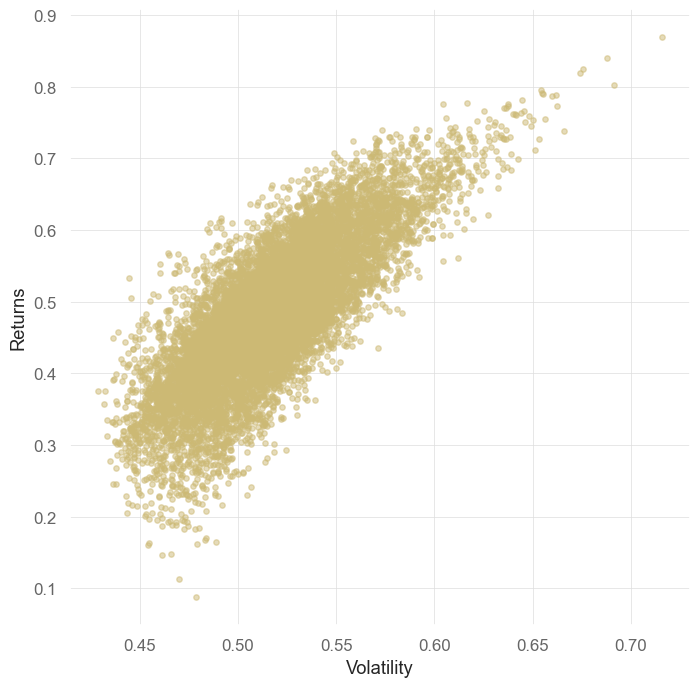

In [140]:
temp.plot.scatter(
    x="Volatility",
    y="Returns",
    marker="o",
    color="y",
    s=15,
    alpha=0.5,
    grid=True,
    figsize=[8, 8],
)

In [160]:
min_vol = temp.iloc[temp["Volatility"].idxmin()]

# risk factor = 0.01
rf = 0.01
optimal_risky_port = temp.iloc[((temp["Returns"] - rf) / temp["Volatility"]).idxmax()]

best_weights = rand_weight_list[((temp["Returns"] - rf) / temp["Volatility"]).idxmax()]

C:\Users\Win\AppData\Local\Temp\ipykernel_20912\2073086864.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(min_vol[1], min_vol[0], color="y", marker="*", s=500)
C:\Users\Win\AppData\Local\Temp\ipykernel_20912\2073086864.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(optimal_risky_port[1], optimal_risky_port[0], color="b", marker="*", s=500)


Text(0, 0.5, 'Expected Returns')

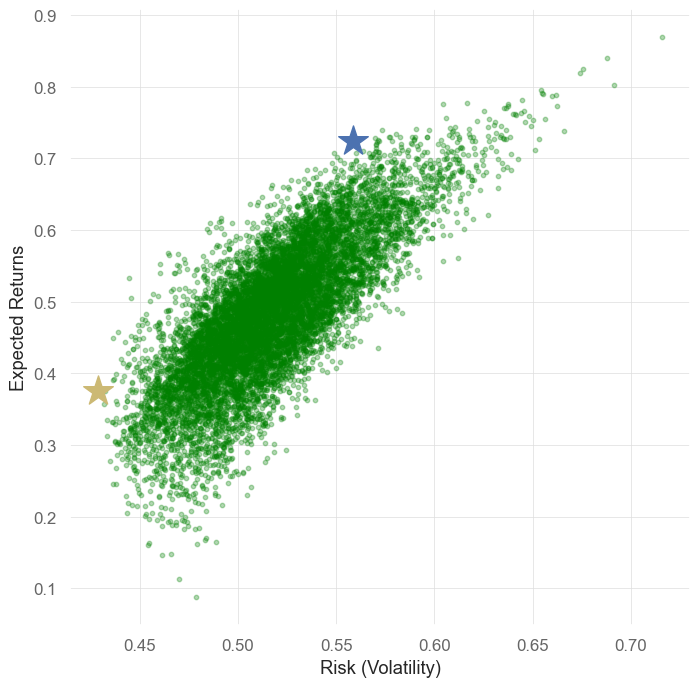

In [144]:
plt.subplots(figsize=(8, 8))
plt.scatter(
    temp["Volatility"], temp["Returns"], marker="o", s=10, alpha=0.3, color="green"
)
plt.scatter(min_vol[1], min_vol[0], color="y", marker="*", s=500)
plt.scatter(optimal_risky_port[1], optimal_risky_port[0], color="b", marker="*", s=500)
plt.xlabel("Risk (Volatility)")
plt.ylabel("Expected Returns")

In [177]:
backtest_rand_weight = generate_random_weight(coins)

random_weight_result = backtest(prices_df, 1000, backtest_rand_weight)
random_weight_result.columns = ["Random"]
best_weight_result = backtest(prices_df, 1000, best_weights)
best_weight_result.columns = ["Best"]

<Axes: xlabel='Date'>

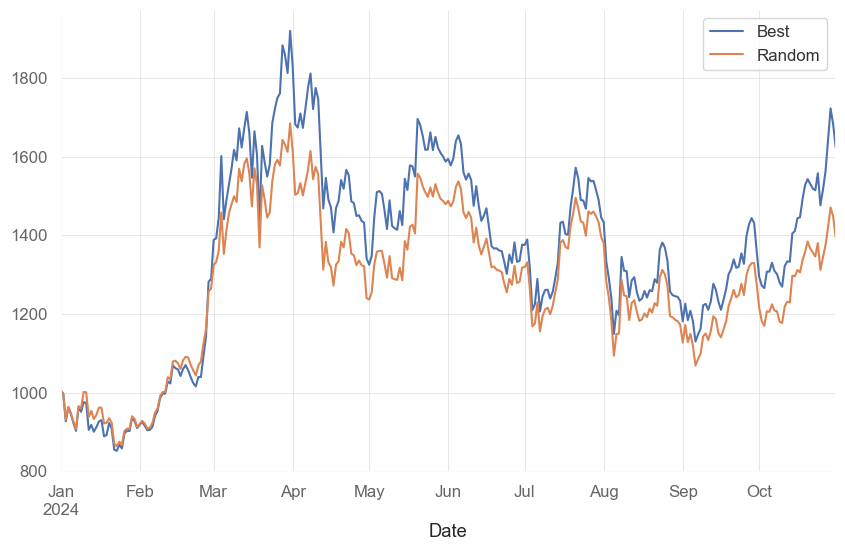

In [178]:
final_result = pd.concat([best_weight_result, random_weight_result], axis=1)
final_result.plot()

# Section 2